In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [7]:
df=pd.read_csv('height-weight.csv')
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0, 0.5, 'height')

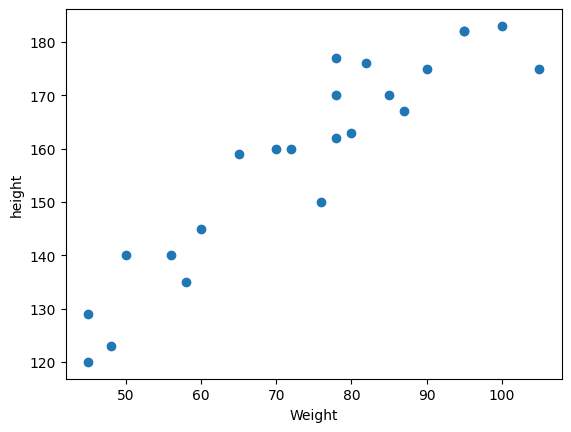

In [9]:
##before making the model leyts visualize the data to find the relation s
plt.scatter(df['Weight'],df['Height'])
plt.xlabel('Weight')
plt.ylabel('height')

In [12]:
## finding the correlation 
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


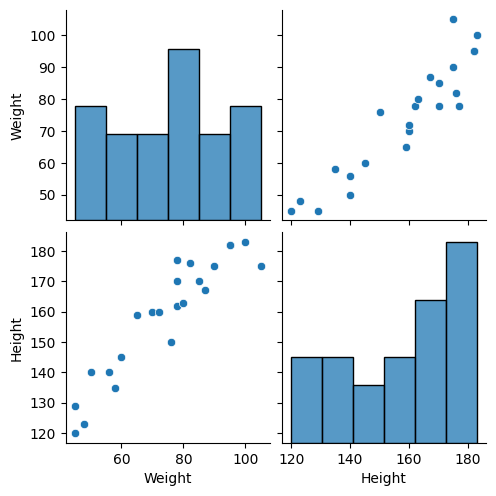

In [13]:
#seaborn for visulaization
import seaborn as sns
sns.pairplot(df)

In [21]:
##idepenedent and dependent features
X=df[['Weight']]#independent feature
#type(X)
##use [[]] and not [] to get a dataframe or a 2d array and not a series or a 1d array
#np.array(X).shape
Y=df['Height']#dependent feature
#this can be in series or 1d array

In [23]:
##Train test split (over and underfit checks)

from sklearn.model_selection import train_test_split

X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.25,random_state=42)

In [24]:
##standardization(Z test used since we need global minima)
from sklearn.preprocessing import StandardScaler


In [27]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)

#so we use fit_transform for train data and just transform for test data
#this is so coz we use the mean and sd of the train data for test data and not the scaler values

In [31]:
X_test=scaler.transform(X_test)
X_test

array([[ 78.],
       [ 78.],
       [ 45.],
       [ 95.],
       [ 65.],
       [105.]])

In [33]:
##apply simple linear regression model
from sklearn.linear_model import LinearRegression
 

In [34]:
regression=LinearRegression()

In [35]:
regression.fit(X_train,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [41]:
regression.coef_
#basically beta 1
#also means with every 1 unit inc in x the coeff inc by that value


array([17.2982057])

In [42]:
regression.intercept_
#basically beta 2

np.float64(156.47058823529412)

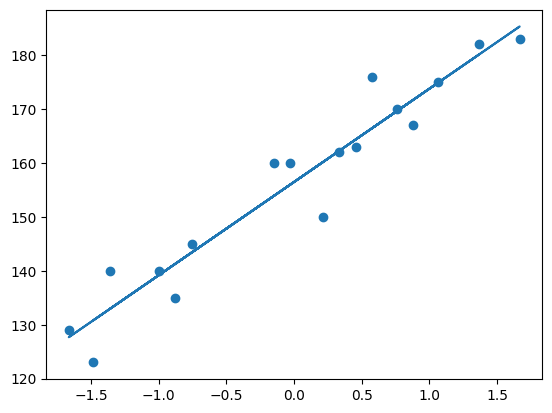

In [45]:
##plot the best fit line wrt train data
plt.scatter(X_train,Y_train)
plt.plot(X_train,regression.predict(X_train))

In [48]:
#prediction for test data
y_pred=regression.predict(X_test)
#it will be in array form  and will be like
#intercept + coeff*X_test

In [ ]:
y_pred

array([1505.73063318, 1505.73063318,  934.88984493, 1799.80013015,
       1280.85395902, 1972.78218719])

In [50]:
##Performance metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [52]:
mse=mean_squared_error(Y_test,y_pred)
mae=mean_absolute_error(Y_test,y_pred)
rmse=np.sqrt(mse)
print("MSE:",mse)
print("MAE:",mae)
print("RMSE:",rmse)

MSE: 1886933.5397307759
MAE: 1336.1312312741586
RMSE: 1373.6569949338793


In [53]:
#r squared value
from sklearn.metrics import r2_score
r2=r2_score(Y_test,y_pred)
print("R2 score:",r2)

R2 score: -4335.393707648128


In [54]:
#adjusted r squared


In [58]:
#doing the same wit ols Linear regression from statsmodels
import statsmodels.api as sm

In [59]:
model=sm.OLS(Y_train,X_train).fit()

In [60]:
model.predict(X_test)

array([1349.26004494, 1349.26004494,  778.4192567 , 1643.32954191,
       1124.38337078, 1816.31159896])

In [61]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Tue, 13 Jan 2026   Prob (F-statistic):                       0.664
Time:                        15:32:31   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            17.2982     39.138      0.442      0.664     -65.671     100.267
==============================================================================
Omnibus:                        0.135   Durbin-Watson:                   0.002
Prob(Omnibus):                  0.935   Jarque-Bera (JB):                0.203
Skew:                          -0.166   Prob(JB):                        0.904
Kurtosis:                       2.581   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [67]:
###prediction for new data
#regression.predict([[72]])
#so we get a value like 1401 which is incorrect so we do standardization first

In [69]:
regression.predict(scaler.transform([[72]]))

array([1401.94139895])